## Day-25 task

(Task no:5-13)

In [2]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt

//Load data:

In [4]:
np.random.seed(42)
data=np.random.normal(loc=50,scale=10,size=60).tolist()
data.extend([150,170,200]) ## add outliers in a list
df=pd.DataFrame({'score':data})
print("Initial Data:\n",df.head())


Initial Data:
        score
0  54.967142
1  48.617357
2  56.476885
3  65.230299
4  47.658466


//Task 5 Boxplot for outlier Visualiztion

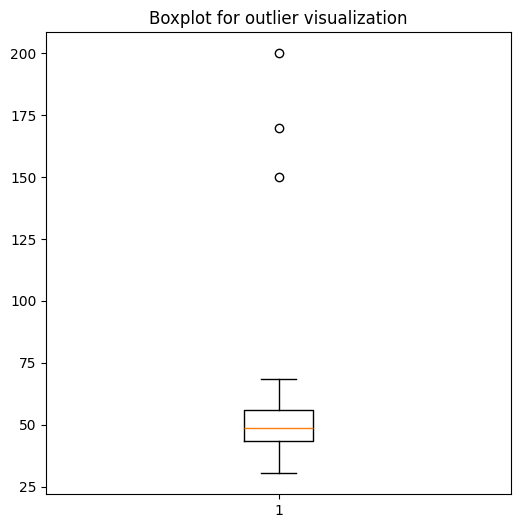

In [5]:
plt.figure(figsize=(6,6))
plt.boxplot(df['score'])
plt.title("Boxplot for outlier visualization")
plt.show()

//Task-6 from scipy.stats import zscore

In [6]:
from scipy.stats import zscore

//Task-7 df[(np.abs(zscore(df['col']))>3)]

In [8]:

z_score_outliers = df[(np.abs(zscore(df['score'])) > 3)]
print("\n7. Z-score Outliers:")
print(z_score_outliers)


7. Z-score Outliers:
    score
60  150.0
61  170.0
62  200.0


//Task-8 Q1=df['col'].quantile(0.25) 

In [9]:
Q1=df['score'].quantile(0.25)
print("value of Q1:\n",Q1)

value of Q1:
 43.60685693732322


///Task-9 Q3=df['col'].quantile(0.75)

In [11]:
Q3=df['score'].quantile(0.75)
print("Value of Q3:\n",Q3)

Value of Q3:
 55.77118166213417


//Task-10 . IQR = Q3 - Q1 

In [12]:
IQR = Q3 - Q1 
print("Value of IQR:",IQR)

Value of IQR: 12.164324724810946


///Task -11 df[(df['col'] < (Q1 - 1.5 * IQR)) | (df['col'] > (Q3 + 1.5 * IQR))] 

In [14]:
outliers=df[(df['score'] < (Q1 - 1.5 * IQR)) | (df['score'] > (Q3 + 1.5 * IQR))] 
print("Outliers:\n",outliers)

Outliers:
     score
60  150.0
61  170.0
62  200.0


//Task-12  df['col'] = np.log1p(df['col']) 

In [15]:
df['score_log'] = np.log1p(df['score'])
print("\n12. After log1p transformation:")
print(df[['score', 'score_log']])


12. After log1p transformation:
         score  score_log
0    54.967142   4.024765
1    48.617357   3.904341
2    56.476885   4.051383
3    65.230299   4.193138
4    47.658466   3.884826
..         ...        ...
58   53.312634   3.994757
59   59.755451   4.106857
60  150.000000   5.017280
61  170.000000   5.141664
62  200.000000   5.303305

[63 rows x 2 columns]


//Task-13 df.loc[df['col'] > upper_bound, 'col'] = upper_bound 

In [19]:
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
print("Lower bound is:\n",lower_bound)
print("Upper bound is:\n",upper_bound)

df.loc[df['score'] < lower_bound, 'score'] = lower_bound
df.loc[df['score'] > upper_bound, 'score'] = upper_bound
print("After capping outliers;\n",df.tail())


Lower bound is:
 25.360369850106803
Upper bound is:
 74.01766874935059
After capping outliers;
         score  score_log
58  53.312634   3.994757
59  59.755451   4.106857
60  74.017669   5.017280
61  74.017669   5.141664
62  74.017669   5.303305
